In [1]:
import pandas as pd
import numpy as np

In [13]:
df =pd.read_csv('Pokemon.csv', encoding = 'unicode_escape')

In [14]:
df.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


In [15]:
types = df['Type 1'].isin(['Grass', 'Fire', 'Water'])
drop_cols = ['Type 1', 'Type 2', 'Generation', 'Legendary']
df = df[types].drop(columns = drop_cols)
df.head()

,#,Name,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed
0,1,Bulbasaur,318,45,49,49,65,65,45
1,2,Ivysaur,405,60,62,63,80,80,60
2,3,Venusaur,525,80,82,83,100,100,80
3,3,VenusaurMega Venusaur,625,80,100,123,122,120,80
4,4,Charmander,309,39,52,43,60,50,65


In [22]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters = 3, random_state = 3)
df['cluster'] = kmeans.fit_predict(df[['Attack','Defense']])

centroids = kmeans.cluster_centers_
cen_x = [i[0] for i in centroids]
cen_y = [i[1] for i in centroids]

df['cen_x'] = df.cluster.map({0: cen_x[0], 1:cen_x[1], 2:cen_x[2]})
df['cen_y'] = df.cluster.map({0: cen_y[0], 1:cen_y[1], 2:cen_y[2]})

colors = ['#DF2020', '#B1DF20', '#2095DF']
df['c'] = df.cluster.map({0: colors[0], 1: colors[1], 2: colors[2]})

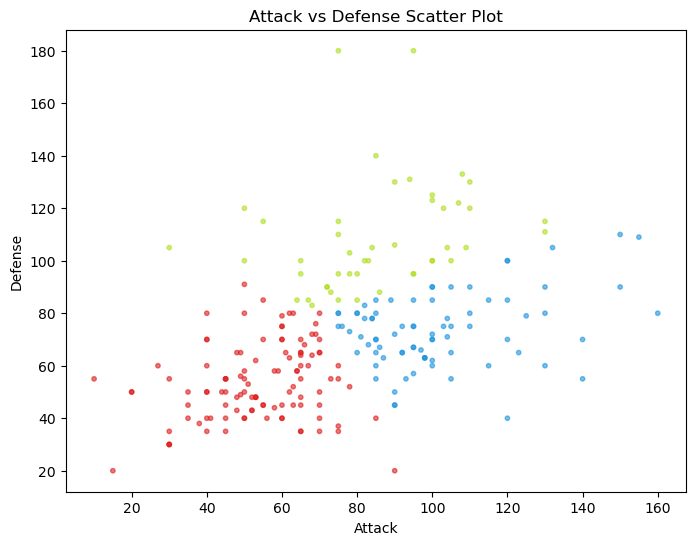

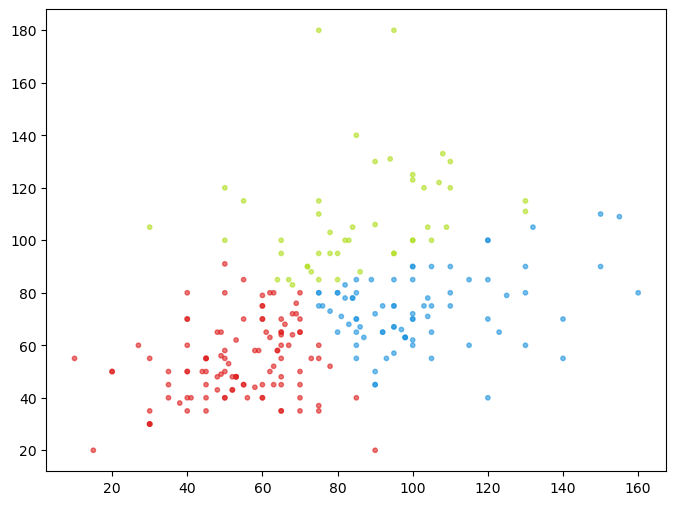

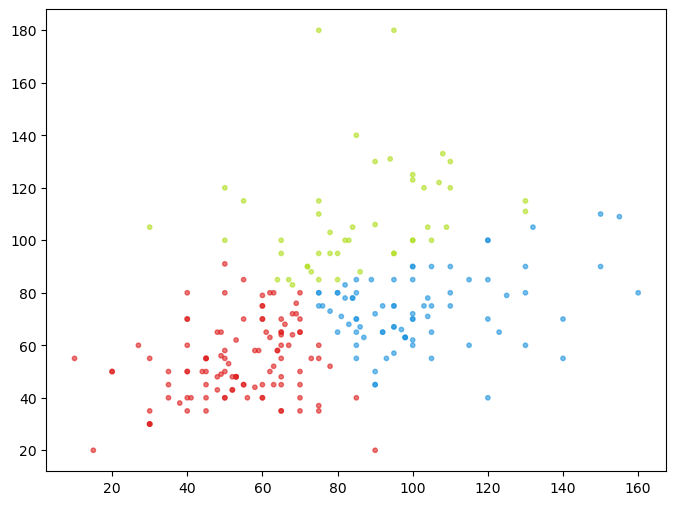

In [27]:
import matplotlib.pyplot as plt
%matplotlib inline

# Scatter plot of Attack vs. Defense with color and transparency
plt.figure(figsize=(8, 6))
plt.scatter(df['Attack'], df['Defense'], c=df['c'], alpha=0.6, s=10)
plt.show()

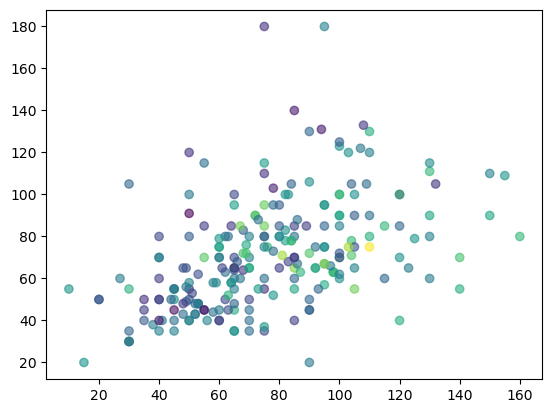

In [30]:
plt.scatter(df['Attack'], df['Defense'], c=df.Speed, alpha=0.6)
plt.show()

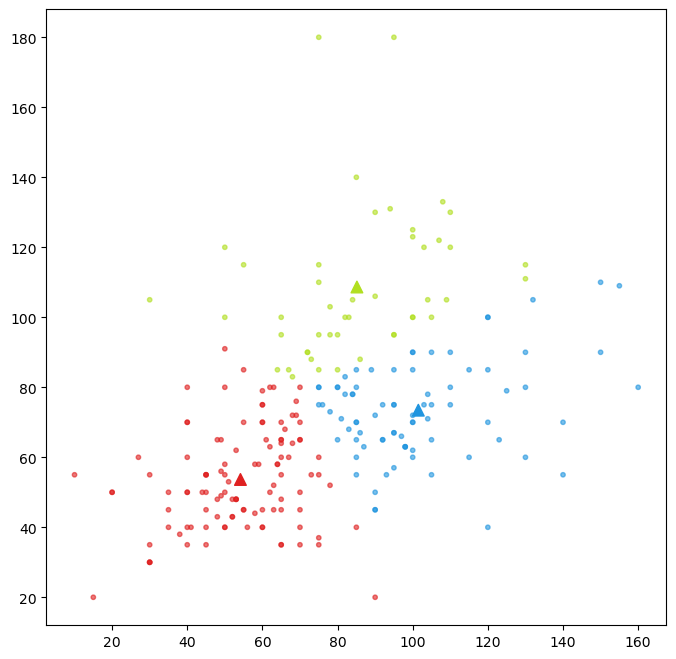

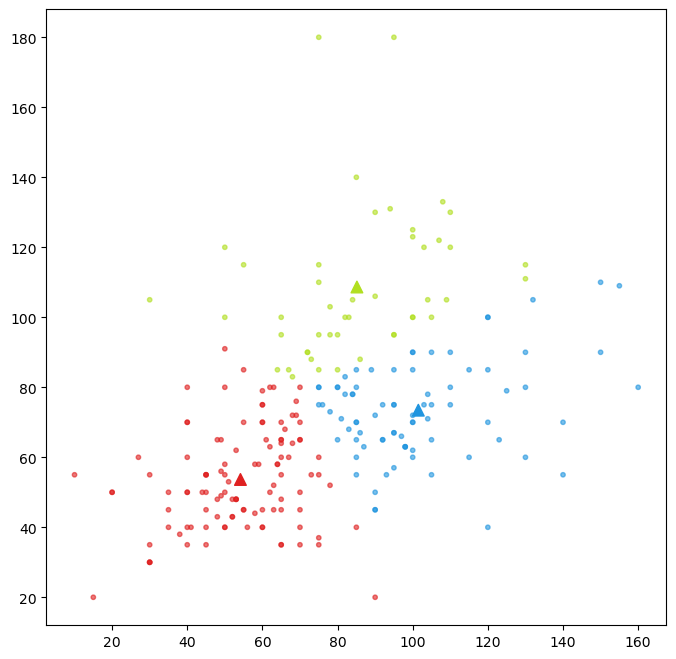

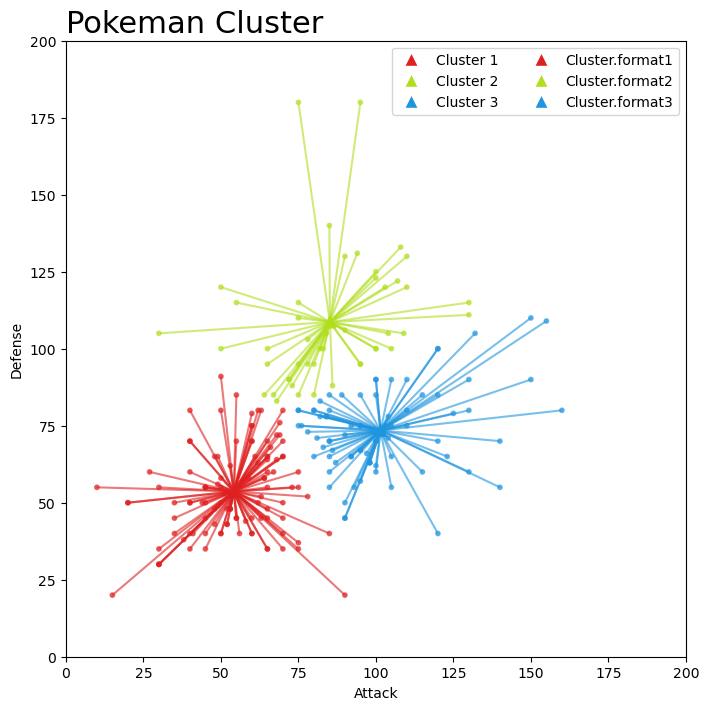

In [56]:
from matplotlib.lines import Line2D
fig, ax = plt.subplots (1, figsize = (8,8))

plt.scatter(df.Attack, df.Defense, c=df.c, alpha=0.6, s=10)
plt.scatter(cen_x, cen_y, marker='^', c=colors, s=70)

for idx, val in df.iterrows():
    x= [val.Attack, val.cen_x]
    y= [val.Defense, val.cen_y]
    plt.plot(x, y, c=val.c, alpha=0.6)

#centroids

cent_leg = [
    Line2D([0], [0], marker='^', color='w', label=f'Centroid - c({i+1})',
           markerfacecolor=mcolor, markersize=10)
    for i, mcolor in enumerate(colors)
]

# Create legend elements for clusters
legend_elements = [
    Line2D([0], [0], marker='^', color='w', label=f'Cluster {i+1}',
           markerfacecolor=mcolor, markersize=10)
    for i, mcolor in enumerate(colors)
]


legend_elements.extend([
    Line2D([0], [0],marker="^", color='w', label=f'Cluster.format{i+1}',
           markerfacecolor=mcolor, markersize=10)
    for i, mcolor in enumerate(colors)
])

plt.legend(handles = legend_elements, loc = "upper right", ncol=2)
plt.xlim(0,200)
plt.ylim(0,200)
plt.title('Pokeman Cluster', loc = 'left', fontsize=22)
plt.xlabel('Attack')
plt.ylabel('Defense')
plt.show()

Hierachical Clustering


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
df = pd.read_csv('Mall_Customers.csv')

In [5]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [34]:
df1 = df.iloc[:, 3:5].values

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

<Figure size 1000x700 with 0 Axes>

<Figure size 1000x700 with 0 Axes>

<Figure size 1000x700 with 0 Axes>

<Figure size 1000x700 with 0 Axes>

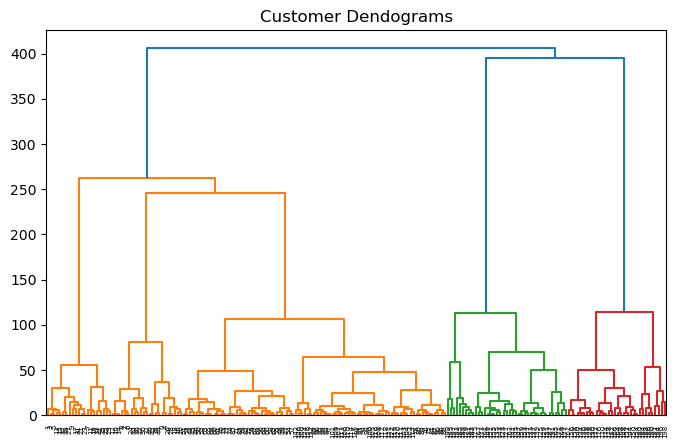

In [37]:
import scipy.cluster.hierarchy as sc

plt.figure(figsize = (8,5))
plt.title("Customer Dendograms")
dend = sc.dendrogram(sc.linkage(df1, method = 'ward'))
plt.show()

In [35]:
from sklearn.cluster import AgglomerativeClustering

model = AgglomerativeClustering(n_clusters=5,  linkage='ward')
labels_ = model.fit_predict(df1)

In [36]:
labels_

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

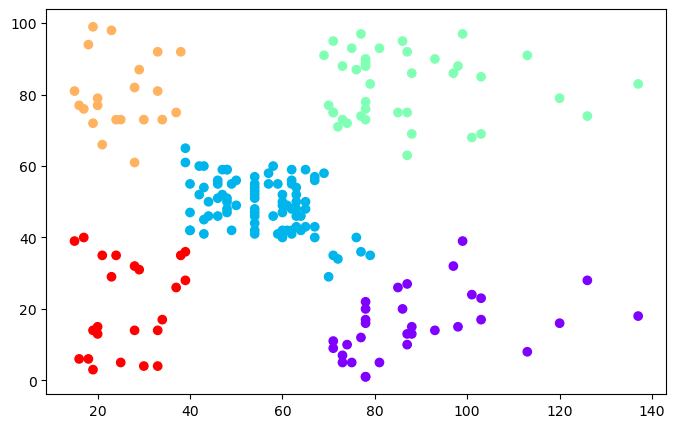

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(df1[:, 0], df1[:, 1], c=model.labels_, cmap='rainbow')
plt.show()

k-Means clustering

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans

In [42]:
df = pd.read_csv('Mall_Customers.csv')

In [43]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [47]:
model = KMeans(n_clusters = 3, init = 'k-means++', random_state = 42)
y_means = model.fit_predict(df.iloc[:,[3,4]].values)

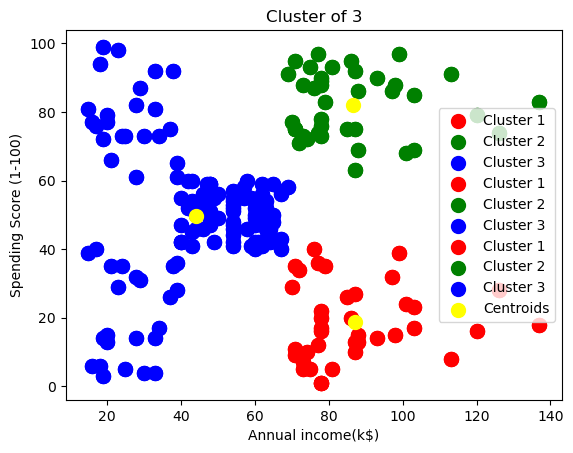

In [50]:
x = df.iloc[:,[3,4]].values
plt.scatter(x[y_means == 0,0], x[y_means == 0,1], s= 100, c='red', label = 'Cluster 1')
plt.scatter(x[y_means == 1,0], x[y_means == 1,1], s= 100, c='green', label = 'Cluster 2')
plt.scatter(x[y_means == 2,0], x[y_means == 2,1], s= 100, c='blue', label = 'Cluster 3')
plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s= 100, c='yellow', label = 'Centroids')
plt.title("Cluster of 3")
plt.xlabel("Annual income(k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

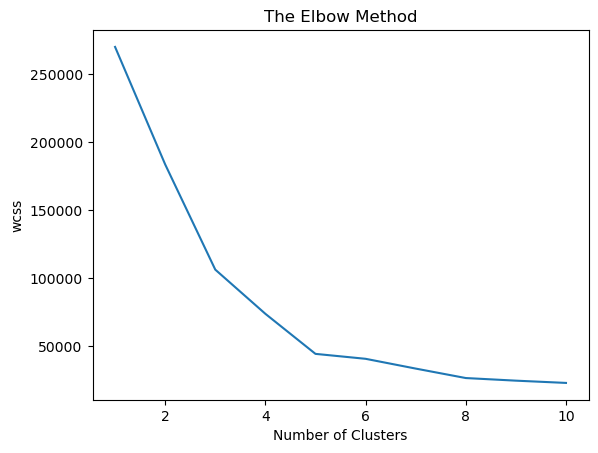

In [57]:
wcss = []
for i in range(1,11):
    model = KMeans(n_clusters=i, init = 'k-means++', random_state = 42)
    model.fit(x)
    wcss.append(model.inertia_)
    
plt.plot(range(1,11), wcss)
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("wcss")
plt.show()

In [59]:
model = KMeans(n_clusters=i, init = 'k-means++', random_state = 42)
y_means = model.fit_predict(x)

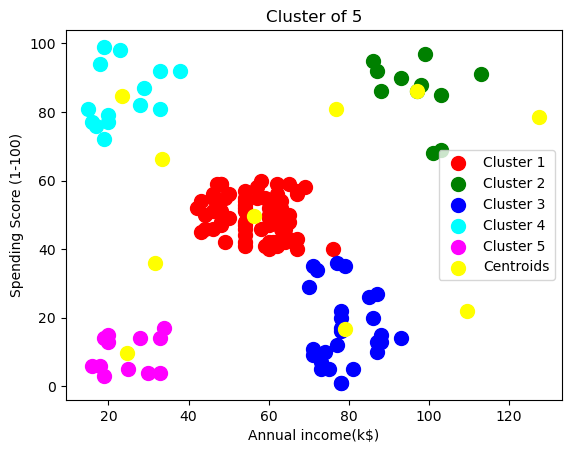

In [60]:
plt.scatter(x[y_means == 0,0], x[y_means == 0,1], s= 100, c='red', label = 'Cluster 1')
plt.scatter(x[y_means == 1,0], x[y_means == 1,1], s= 100, c='green', label = 'Cluster 2')
plt.scatter(x[y_means == 2,0], x[y_means == 2,1], s= 100, c='blue', label = 'Cluster 3')
plt.scatter(x[y_means == 3,0], x[y_means == 3,1], s= 100, c='cyan', label = 'Cluster 4')
plt.scatter(x[y_means == 4,0], x[y_means == 4,1], s= 100, c='magenta', label = 'Cluster 5')

plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1], s= 100, c='yellow', label = 'Centroids')
plt.title("Cluster of 5")
plt.xlabel("Annual income(k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

Outlier Value Decomposition

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [11]:
sd = pd.read_csv('https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv')

In [12]:
sd.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [13]:
df = sd[['sepal.length','sepal.width']]

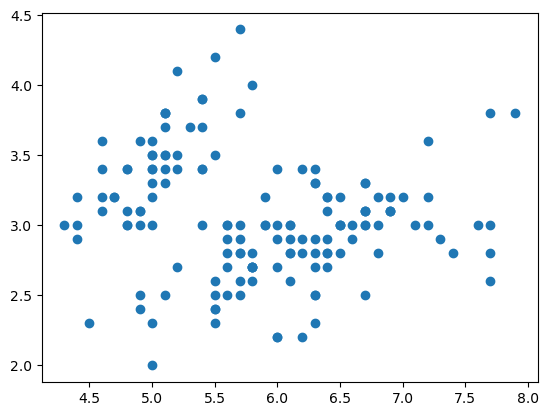

In [27]:
plt.scatter(df['sepal.length'],df['sepal.width'])

In [20]:
x = df.values
nbrs = NearestNeighbors(n_neighbors = 3)
nbrs.fit(x)

NearestNeighbors(n_neighbors=3)

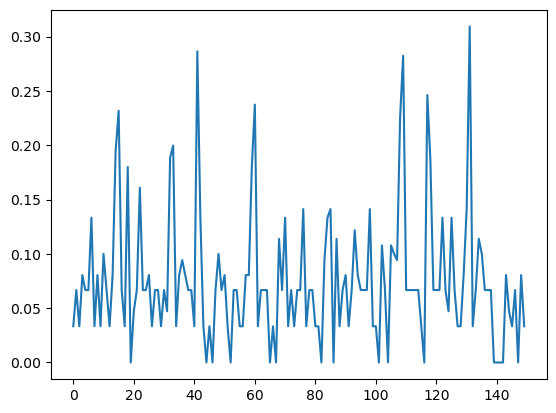

In [21]:
distance, indexes = nbrs.kneighbors(x)
plt.plot(distance.mean(axis = 1))

In [22]:
outlier_index = np.where(distance.mean(axis = 1)> 0.15)
outlier_index

(array([ 14,  15,  18,  22,  32,  33,  41,  59,  60, 108, 109, 117, 118,
        131]),)

In [25]:
outlier_values = df.iloc[outlier_index]
outlier_values

,sepal.length,sepal.width
14,5.8,4.0
15,5.7,4.4
18,5.7,3.8
22,4.6,3.6
32,5.2,4.1
33,5.5,4.2
41,4.5,2.3
59,5.2,2.7
60,5.0,2.0
108,6.7,2.5


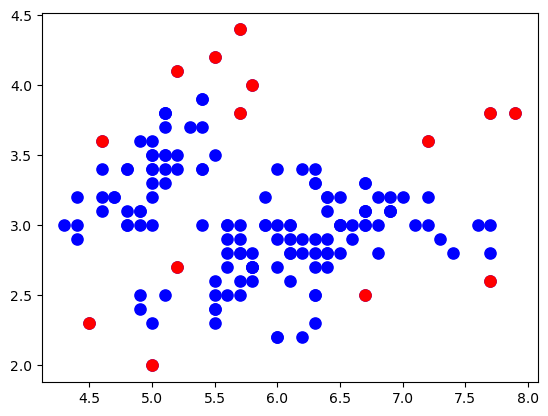

In [26]:
plt.scatter(df['sepal.length'],df['sepal.width'], c = 'b', s = 65)
plt.scatter(outlier_values['sepal.length'],outlier_values['sepal.width'], c = 'r', s = 65)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

In [3]:
cancer = load_breast_cancer()
print(cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [4]:
df =pd.DataFrame(cancer['data'], columns= cancer['feature_names'])
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [9]:
x_train, x_test = train_test_split(df, test_size = 0.2, random_state = 42)
sc = StandardScaler()
sc.fit(x_train)
x_train_std = sc.transform(x_train)
x_test_std = sc.transform(x_test)

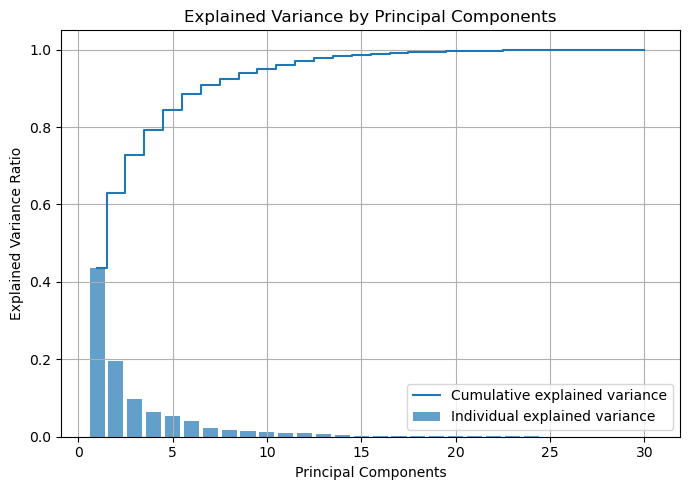

In [11]:
pca = PCA()
# Apply PCA
x_trian_pca = pca.fit_transform(x_train_std)

# Explained variance
exp_var_pca = pca.explained_variance_ratio_
cum_sum_eigenvalues = np.cumsum(exp_var_pca)

plt.figure(figsize=(7, 5))
plt.bar(range(1, len(exp_var_pca) + 1), exp_var_pca, alpha=0.7, align='center', label='Individual explained variance')
plt.step(range(1, len(cum_sum_eigenvalues) + 1), cum_sum_eigenvalues, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance by Principal Components')
plt.legend(loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

SVD

In [16]:
import pandas as pd
c_names = ['post1','post2','post3','post4']
words = ['ice','tahoe','snow','ghost','puck']
post_words = pd.DataFrame([[4,4,6,3],
                           [6,1,0,5],
                           [3,0,0,5],
                           [0,6,5,1],
                           [0,4,5,0]], index = words, columns = c_names)
post_words.index.names = ['word:']
post_words

,post1,post2,post3,post4
word:,,,,
ice,4,4,6,3
tahoe,6,1,0,5
snow,3,0,0,5
ghost,0,6,5,1
puck,0,4,5,0


In [18]:
import numpy as np
U, sigma, V = np.linalg.svd(post_words)
print(np.round(V,decimals  = 2))

[[-0.4  -0.55 -0.61 -0.4 ]
 [-0.58  0.37  0.44 -0.58]
 [ 0.56 -0.46  0.41 -0.55]
 [-0.42 -0.59  0.52  0.45]]


In [19]:
sigma

array([13.55940373,  9.25515187,  2.06889804,  1.48472053])

In [20]:
A_approx = np.matrix(U[:, :2]) *np.diag(sigma[:2]) * np.matrix(V[:2, :])
print(pd.DataFrame(A_approx, index = words, columns = c_names))

          post1     post2     post3     post4
ice    3.501303  4.788264  5.303188  3.479141
tahoe  5.534524  0.532173  0.412075  5.484183
snow   4.012803  0.069590 -0.059468  3.975616
ghost  0.507972  5.117862  5.779698  0.514380
puck  -0.008175  4.232570  4.794681  0.001110


In [22]:
print(post_words - A_approx)

          post1     post2     post3     post4
word:                                        
ice    0.498697 -0.788264  0.696812 -0.479141
tahoe  0.465476  0.467827 -0.412075 -0.484183
snow  -1.012803 -0.069590  0.059468  1.024384
ghost -0.507972  0.882138 -0.779698  0.485620
puck   0.008175 -0.232570  0.205319 -0.001110


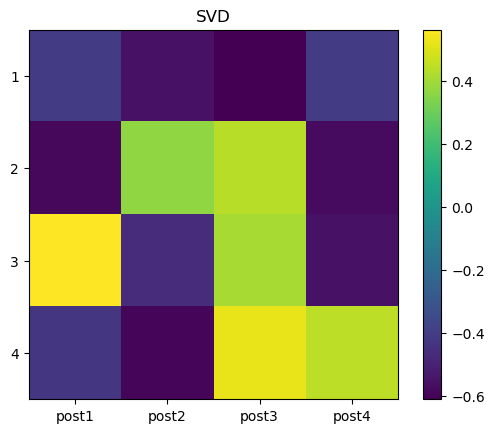

In [25]:
import matplotlib.pyplot as plt

plt.imshow(V, interpolation='none')
plt.xticks(range(len(c_names)))
plt.yticks(range(len(words)))
plt.ylim([len(words) -1.5, -.5])
ax = plt.gca()
ax.set_xticklabels(c_names)
ax.set_yticklabels(range(1, len(words) +1))
plt.title("SVD")
plt.colorbar()

In [26]:
pd.DataFrame(U[:, 1], index = words)

,0
ice,0.001447
tahoe,-0.651258
snow,-0.501568
ghost,0.411023
puck,0.394145


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.datasets import make_blobs
from sklearn.cluster import Birch

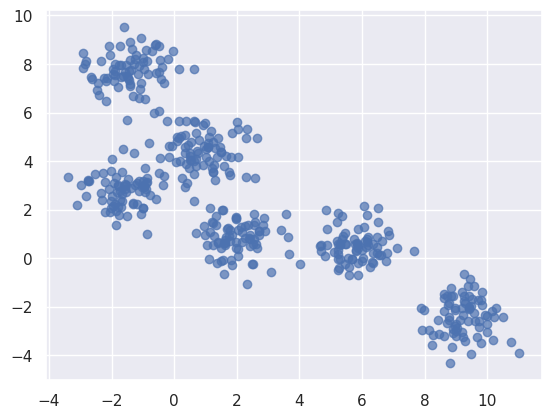

In [3]:
x, clusters = make_blobs(n_samples = 450, centers = 6, cluster_std = 0.7, random_state = 0)
plt.scatter(x[:,0], x[:, 1], alpha = 0.7, edgecolors = 'b')

In [5]:
brc = Birch(branching_factor = 50, n_clusters = None,threshold = 1.5)
brc.fit(x)

Birch(n_clusters=None, threshold=1.5)

In [6]:
labels = brc.predict(x)

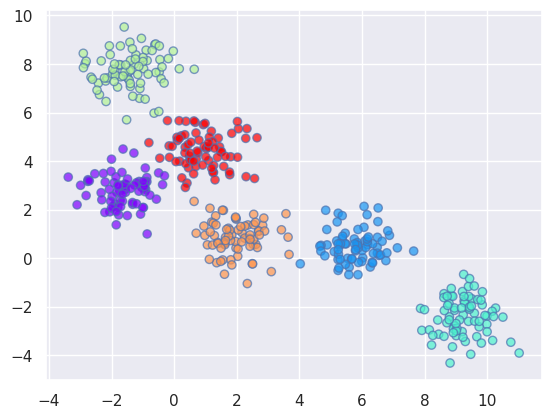

In [7]:
plt.scatter(x[:,0],x[:,1], c =labels, cmap = 'rainbow', alpha = 0.7, edgecolors = 'b')

Ensemble Learning